# Mutual Fund Analytics Platform - Exploratory Data Analysis (EDA)

**Project:** Bluestock Fintech Capstone

**Objective:**
Analyze mutual fund performance, NAV trends, investor behavior, AUM growth, category inflows, and portfolio allocation using Python visualizations.

---

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display all columns if needed
pd.set_option("display.max_columns", None)

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")
transactions = pd.read_csv("../data/processed/clean_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [3]:
datasets = {
    "Fund Master": fund_master,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)


## NAV Trend Analysis (2022–2026)

This visualization shows the daily Net Asset Value (NAV) movement for all mutual fund schemes. Shaded regions indicate major market events, including the 2023 bull run and the 2024 market correction.

In [4]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Merge scheme names
nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_plot.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [5]:
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "scheme_name": "Scheme"
    }
)

# Highlight Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Market Correction
fig.add_vrect(
    x0="2024-07-01",
    x1="2024-10-31",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    height=700
)

fig.show()

fig.write_image("../reports/charts/nav_trend.png")

### Insight 1

The NAV trend shows consistent long-term growth across most schemes, with stronger upward momentum during 2023 and periods of increased volatility during the highlighted 2024 market correction.

## AUM Growth by Fund House (2022–2025)

This visualization compares the Assets Under Management (AUM) of major fund houses across different years. SBI Mutual Fund is highlighted due to its market-leading AUM.

In [6]:
# Convert date column
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Aggregate yearly AUM
aum_year = (
    aum.groupby(["year", "fund_house"])["aum_lakh_crore"]
       .sum()
       .reset_index()
)

aum_year.head()

,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,5.63
1,2022,Axis Mutual Fund,4.90
2,2022,DSP Mutual Fund,2.22
3,2022,HDFC Mutual Fund,8.80
4,2022,ICICI Prudential MF,9.53


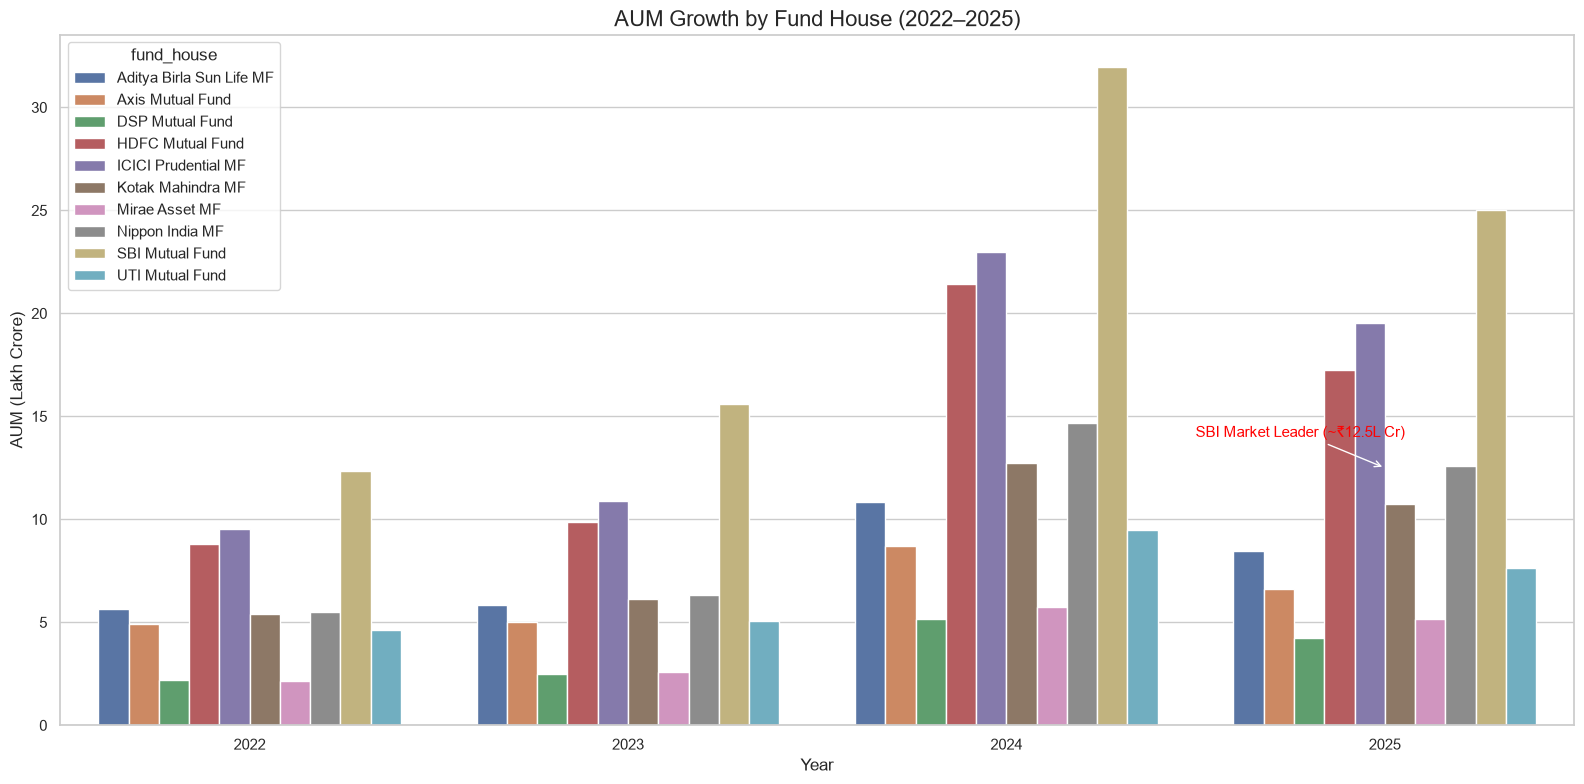

In [7]:
plt.figure(figsize=(16,8))

ax = sns.barplot(
    data=aum_year,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

# Highlight SBI
plt.annotate(
    "SBI Market Leader (~₹12.5L Cr)",
    xy=(3, 12.5),
    xytext=(2.5, 14),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11,
    color="red"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 2

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), demonstrating its dominant position in the Indian mutual fund industry during the analysis period.

## Monthly SIP Inflow Trend (2022–2025)

This visualization presents the monthly SIP inflows from January 2022 to December 2025. The chart highlights the record SIP inflow of ₹31,002 Crore achieved in December 2025.

In [8]:
# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Find highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"All-Time High<br>₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()
# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Find highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"].strftime("%Y-%m-%d"),
    y=max_row["sip_inflow_crore"],
    text=f"All-Time High<br>₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()
fig.write_image("../reports/charts/sip_inflow_trend.png")

## Category-wise Net Inflow Heatmap

This heatmap illustrates monthly net inflows across mutual fund categories. Darker colors represent higher net inflows, making it easy to identify which categories attracted the most investments over time.

In [9]:
# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Format month for display
category["month_name"] = category["month"].dt.strftime("%b-%Y")

# Pivot table
heatmap_data = category.pivot_table(
    index="category",
    columns="month_name",
    values="net_inflow_crore",
    aggfunc="sum"
)

heatmap_data.head()

month_name,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


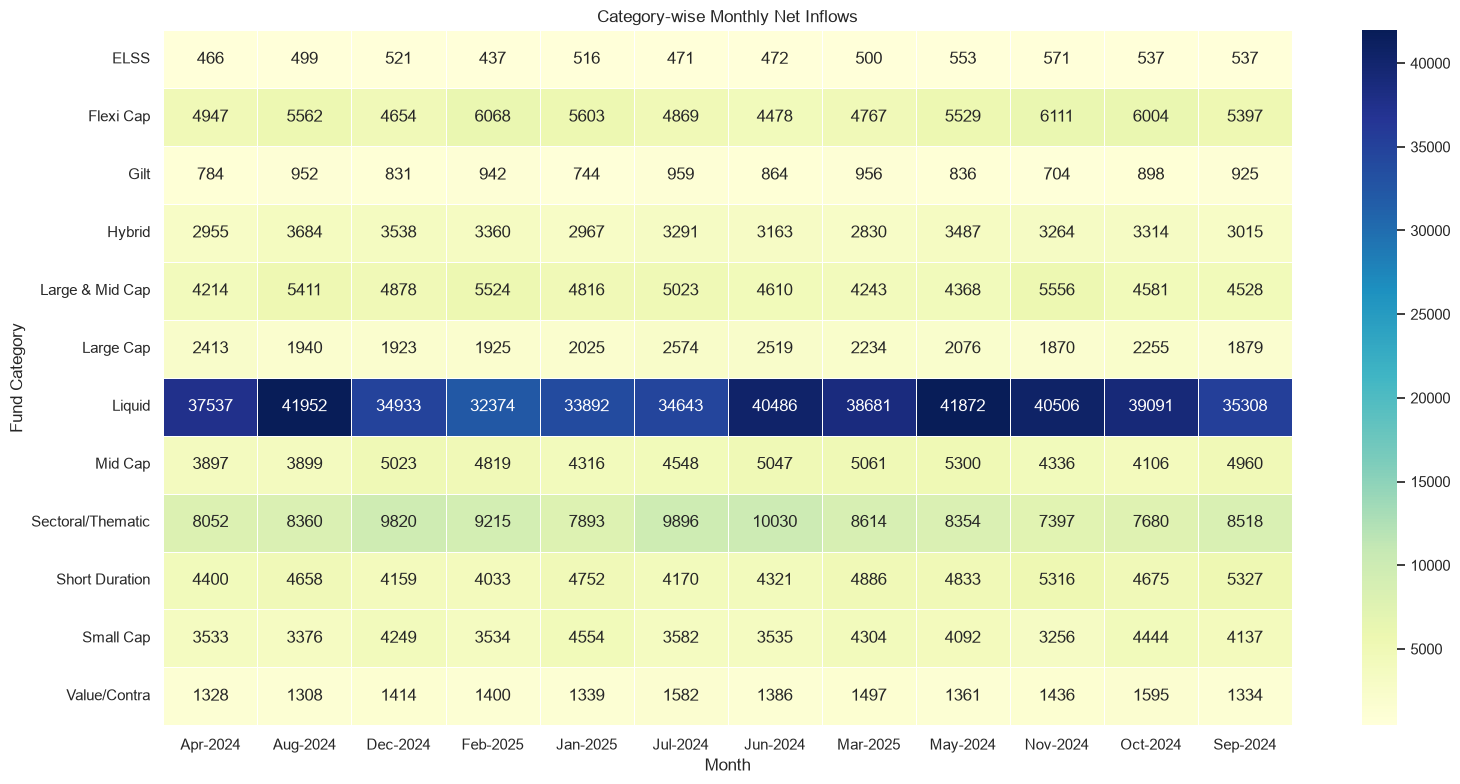

In [10]:
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Monthly Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../reports/charts/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 4

The heatmap reveals that equity-oriented categories such as Large Cap, Mid Cap, and Flexi Cap consistently attracted strong monthly inflows, while other categories experienced more moderate or cyclical investment patterns.

## Investor Demographics

This section analyzes investor demographics, including age distribution, investment behavior across age groups, and gender participation.

In [11]:
age_counts = transactions["age_group"].value_counts()

fig = px.pie(
    values=age_counts.values,
    names=age_counts.index,
    title="Investor Age Group Distribution"
)

fig.update_traces(textposition="inside", textinfo="percent+label")

fig.show()

fig.write_image("../reports/charts/age_group_distribution.png")

### Insight 5

The majority of investors belong to the middle-age segments, indicating that working professionals contribute significantly to mutual fund investments.

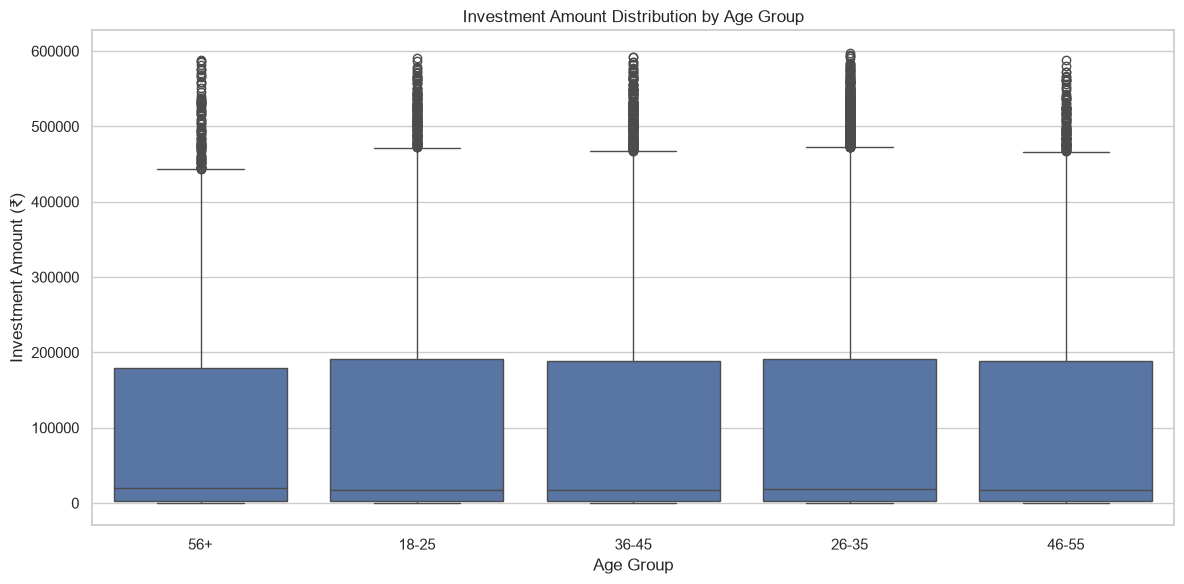

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/age_group_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 6

Older investors generally exhibit higher investment amounts and greater variability, while younger investors tend to invest smaller and more consistent amounts.

In [13]:
gender_counts = transactions["gender"].value_counts()

fig = px.pie(
    values=gender_counts.values,
    names=gender_counts.index,
    title="Gender Distribution of Investors"
)

fig.update_traces(textposition="inside", textinfo="percent+label")

fig.show()

fig.write_image("../reports/charts/gender_distribution.png")

### Insight 7

The gender distribution provides an overview of participation across investor groups and helps identify demographic representation within the dataset.

## Geographic Distribution

This section analyzes investor participation across Indian states and compares investments from T30 and B30 cities.

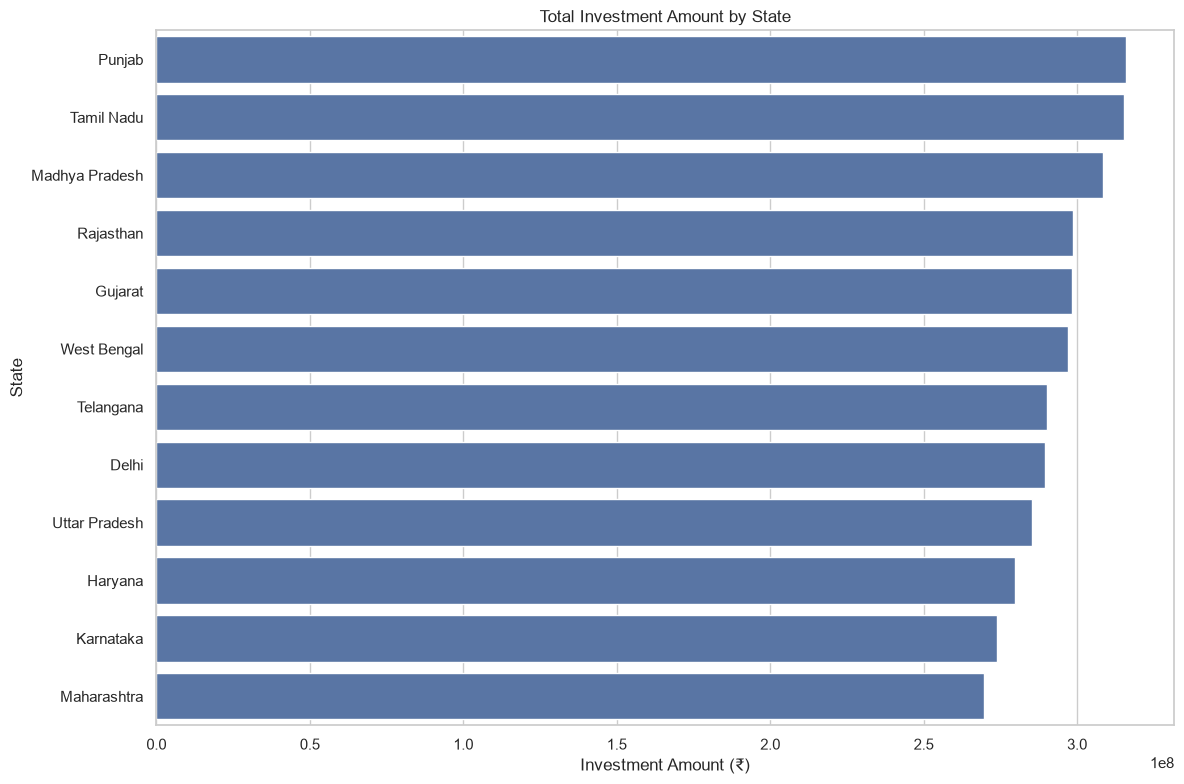

In [14]:
state_data = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_data.values,
    y=state_data.index
)

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/charts/state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 8

A few states contribute a significant share of total investments, indicating higher mutual fund penetration and investor participation in those regions.

In [15]:
tier_counts = transactions["city_tier"].value_counts()

fig = px.pie(
    values=tier_counts.values,
    names=tier_counts.index,
    title="Investor Distribution: T30 vs B30 Cities"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

fig.write_image(
    "../reports/charts/t30_b30_distribution.png"
)

### Insight 9

The comparison between T30 and B30 cities highlights the geographic spread of mutual fund investments and the growing participation from non-metro regions.

## Industry Folio Growth (2022–2025)

This chart illustrates the steady growth in mutual fund folios from January 2022 to December 2025, demonstrating the increasing adoption of mutual fund investments across India.

In [17]:


# Convert month column
folio["month"] = pd.to_datetime(folio["month"])

# Create line chart
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Industry Folio Growth (2022–2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    }
)

# Starting milestone
fig.add_annotation(
    x="2022-01-01",
    y=13.26,
    text="13.26 Cr<br>Jan 2022",
    showarrow=True,
    arrowhead=2,
    bgcolor="lightgreen"
)

# Ending milestone
fig.add_annotation(
    x="2025-12-01",
    y=26.12,
    text="26.12 Cr<br>Dec 2025",
    showarrow=True,
    arrowhead=2,
    bgcolor="lightblue"
)

# Improve layout
fig.update_layout(
    template="plotly_white",
    height=600,
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)

# Show chart
fig.show()

# Export chart
fig.write_image(
    "../reports/charts/folio_growth.png",
    width=1400,
    height=700,
    scale=2
)

### Insight 10

The total number of mutual fund folios increased steadily from **13.26 crore in January 2022** to **26.12 crore in December 2025**, reflecting strong growth in investor participation and sustained expansion of the Indian mutual fund industry.

## NAV Return Correlation Matrix

This analysis measures how the daily returns of selected mutual fund schemes move relative to one another. Higher correlation values indicate similar price movement patterns.

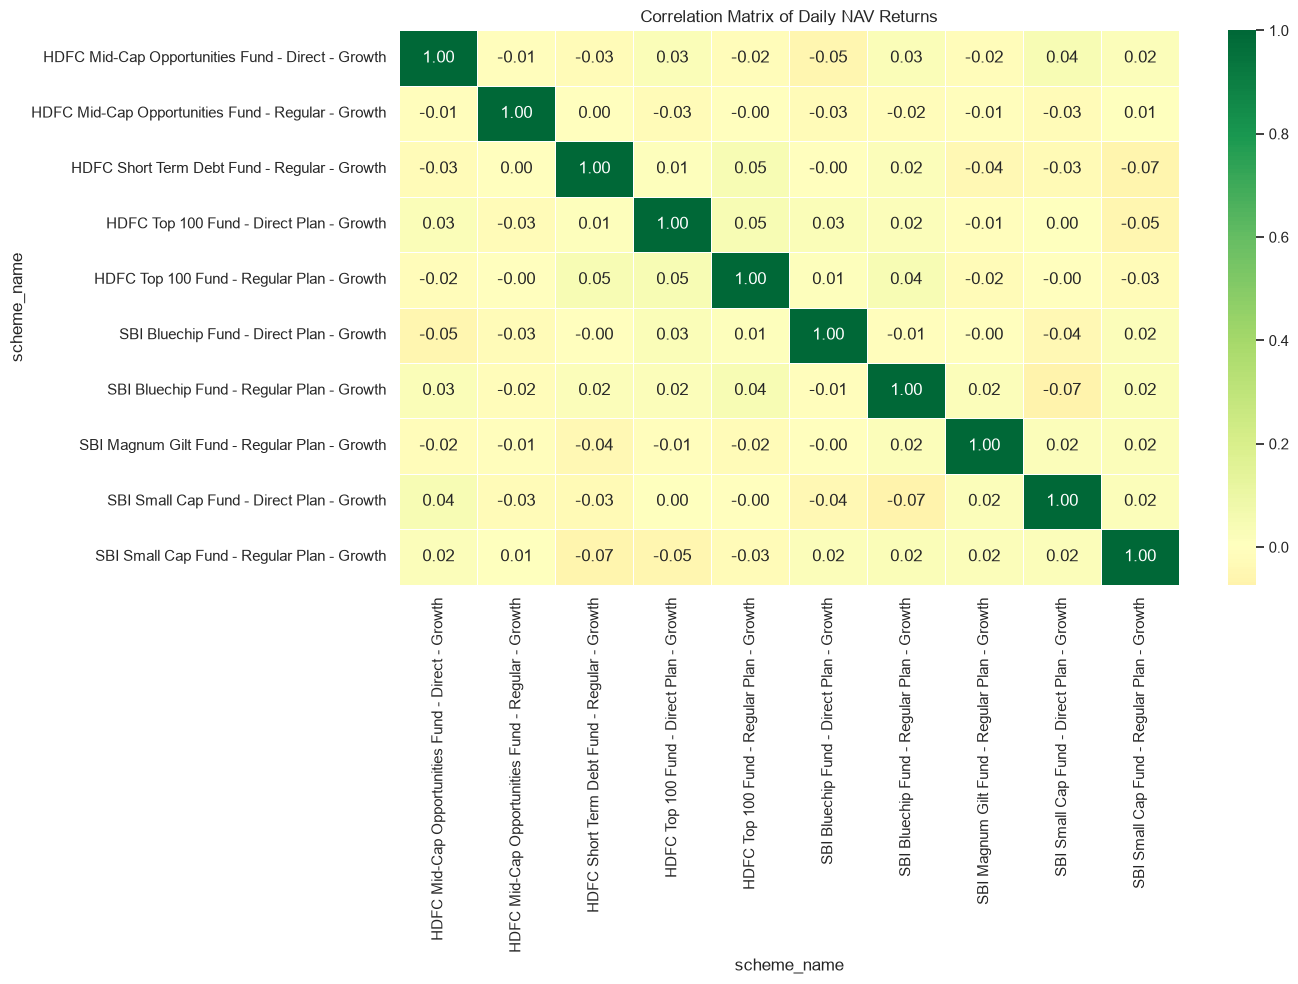

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select first 10 schemes
selected_funds = performance["amfi_code"].head(10)

# Filter NAV data
corr_df = nav[nav["amfi_code"].isin(selected_funds)].copy()

# Merge scheme names
corr_df = corr_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Ensure proper ordering
corr_df["date"] = pd.to_datetime(corr_df["date"])

# Create pivot table
pivot = corr_df.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Daily percentage returns
daily_returns = pivot.pct_change().dropna()

# Correlation matrix
corr_matrix = daily_returns.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 11

Large-cap schemes from the same fund house exhibit stronger positive correlations, while debt-oriented schemes demonstrate comparatively weaker relationships with equity funds, highlighting the diversification benefits across asset classes.

## Sector Allocation Across Equity Funds

This donut chart summarizes the aggregate portfolio allocation across different market sectors. It helps identify which industries receive the largest investment exposure across all equity mutual funds.

In [21]:
# Aggregate sector weights
sector_data = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.pie(
    sector_data,
    values="weight_pct",
    names="sector",
    hole=0.45,
    title="Sector Allocation Across Equity Funds"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    template="plotly_white",
    height=700
)

fig.show()

fig.write_image(
    "../reports/charts/sector_allocation_donut.png"
)

### Insight 12

Banking, Information Technology, Pharma, and Financial Services account for a significant proportion of portfolio allocation, reflecting the strong preference for established sectors in diversified equity mutual funds.

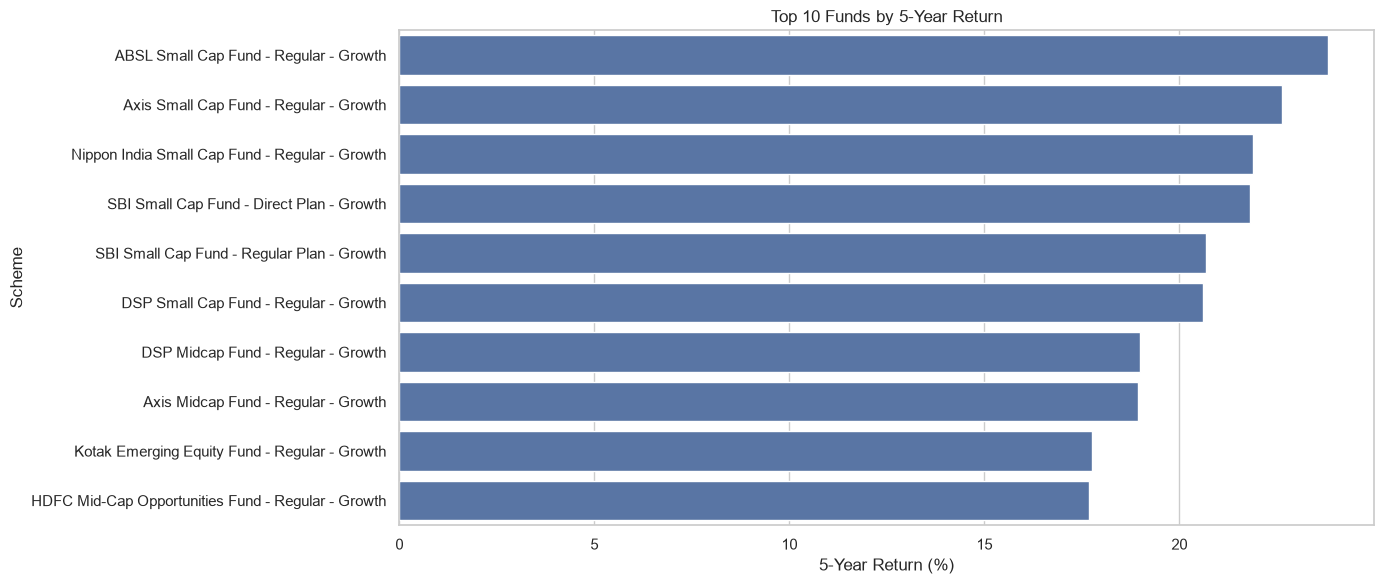

In [22]:
top10 = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top10_returns.png",
    dpi=300
)

plt.show()

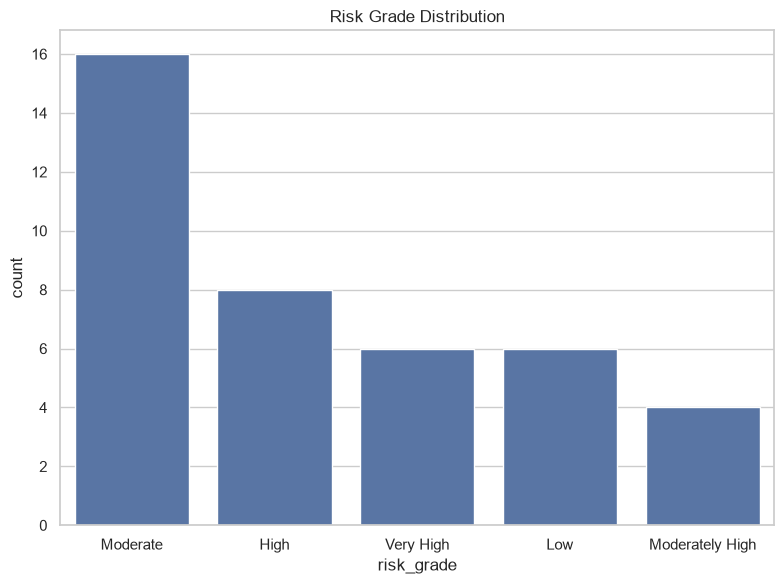

In [23]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=performance,
    x="risk_grade",
    order=performance["risk_grade"].value_counts().index
)

plt.title("Risk Grade Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/charts/risk_distribution.png",
    dpi=300
)

plt.show()

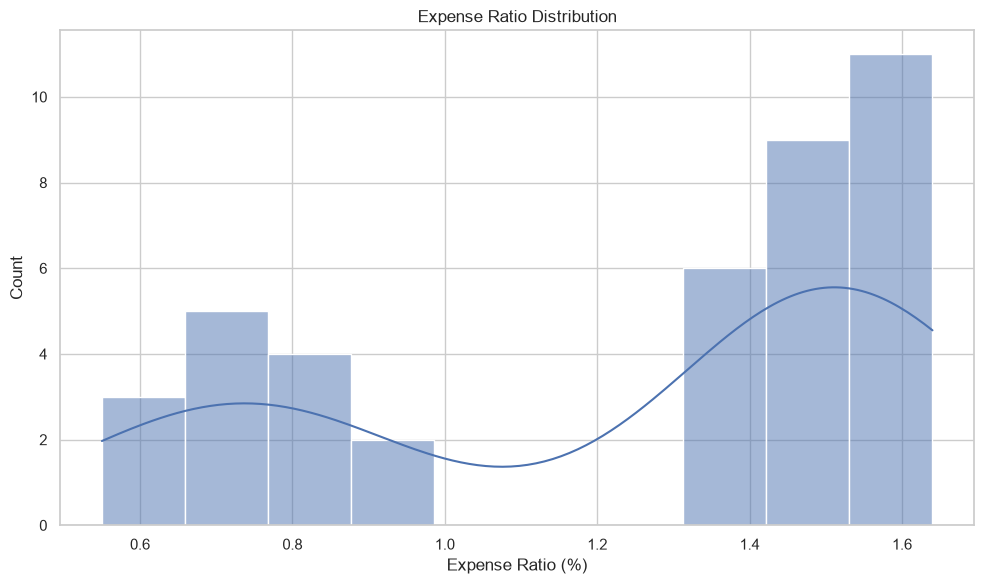

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/expense_ratio_distribution.png",
    dpi=300
)

plt.show()

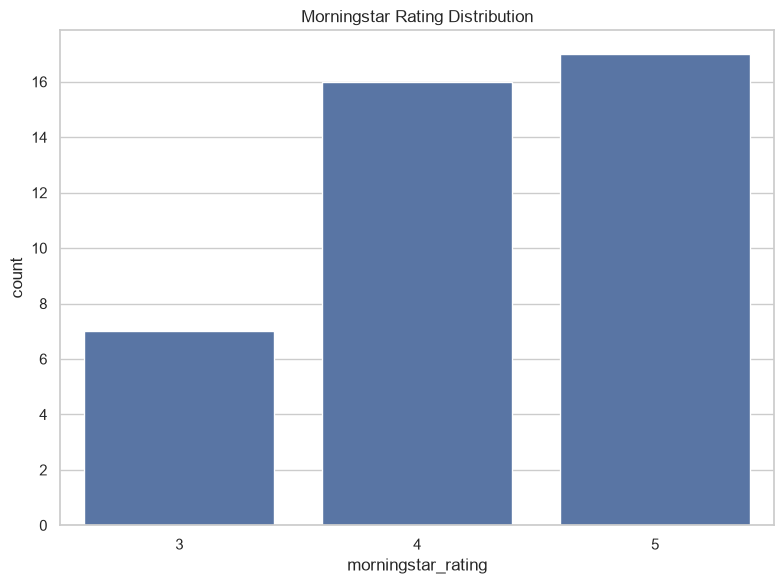

In [25]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/charts/morningstar_ratings.png",
    dpi=300
)

plt.show()